# Фильтрация и обрезка сообщений

## Обзор

Теперь мы лучше понимаем несколько вещей:

* Как настраивать схему состояния графа
* Как определять пользовательские редьюсеры состояния
* Как использовать несколько схем состояния графа

## Цели

Теперь мы можем начать применять эти концепции вместе с моделями в LangGraph!

В следующих нескольких сессиях мы будем двигаться к созданию чат-бота с долговременной памятью.

Поскольку наш чат-бот будет использовать сообщения, давайте сначала поговорим о более продвинутых способах работы с сообщениями в состоянии графа.

In [1]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from langchain_gigachat import GigaChat

In [2]:
import os
api_key = os.getenv("GIGA_API_KEY")

In [3]:
llm = llm_01 = GigaChat(
    credentials = api_key,
    verify_ssl_certs=False,
    scope = 'GIGACHAT_API_CORP',
    temperature=0.1,
    profanity_check = False,
    model="GigaChat",
)

## Messages as state

In [4]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

# Создаем список сообщений
messages = [AIMessage(f"Итак, вы сказали, что изучаете морских млекопитающих?", name="Бот")]
# Добавляем сообщение от пользователя
messages.append(HumanMessage(f"Да, я знаю о китах. Но о каких еще животных мне стоит узнать?", name="Лэнс"))

# Выводим каждое сообщение в удобном формате
for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Бот

Итак, вы сказали, что изучаете морских млекопитающих?
================================ Human Message =================================
Name: Лэнс

Да, я знаю о китах. Но о каких еще животных мне стоит узнать?


In [5]:
llm.invoke(messages)

AIMessage(content='Отличный выбор! Морские млекопитающие действительно удивительны и разнообразны. Помимо китов, есть множество других интересных видов, которые могут вас заинтересовать. Вот несколько примеров:\n\n1. **Дельфины** – это одни из самых умных морских млекопитающих. Они обладают развитой социальной структурой и сложным поведением. Дельфины живут как в океанах, так и в реках (например, амазонский дельфин).\n\n2. **Тюлени** – эти животные относятся к семейству ластоногих. Тюлени обитают по всему миру, от Арктики до Антарктики. Они имеют уникальные адаптации для жизни в воде и на суше.\n\n3. **Моржи** – крупные морские млекопитающие с массивными клыками. Они живут в арктических водах и известны своими социальными взаимодействиями и миграциями.\n\n4. **Кашалоты** – глубоководные хищники, известные своим огромным размером и мощной челюстью. Кашалоты часто встречаются в тропических и умеренных водах.\n\n5. **Косатки** – также известные как "киты-убийцы", косатки являются одними и

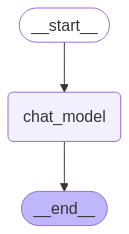

In [6]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END

# Node
def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Бот

Итак, вы сказали, что изучаете морских млекопитающих?
================================ Human Message =================================
Name: Лэнс

Да, я знаю о китах. Но о каких еще животных мне стоит узнать?
================================== Ai Message ==================================

Отличный выбор! Морские млекопитающие действительно удивительны и разнообразны. Помимо китов, есть множество других интересных видов, которые могут вас заинтересовать. Вот несколько примеров:

1. **Дельфины** – это одни из самых умных морских млекопитающих. Они обладают развитой социальной структурой и сложным языком общения. Дельфины живут как в океанах, так и в реках (например, амазонский дельфин).

2. **Тюлени** – эти животные относятся к семейству ластоногих. Тюлени обитают по всему миру, от Арктики до Антарктики. Они имеют толстый слой жира, который помогает им сохранять тепло в холодных водах.

3. **Морж

## Редьюсер
## Reducer

Практическая проблема при работе с сообщениями — управление длительными диалогами. 

Длительные диалоги приводят к высокому потреблению токенов и задержкам, если мы не будем осторожны, потому что мы передаем растущий список сообщений модели.

У нас есть несколько способов решить эту проблему.

- Во-первых, вспомним трюк, который мы видели с использованием `RemoveMessage` и редьюсера `add_messages`.

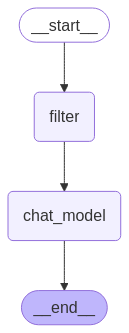

In [8]:
from langchain_core.messages import RemoveMessage

# Nodes
def filter_messages(state: MessagesState):
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):    
    return {"messages": [llm.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
# Список сообщений с преамбулой
messages = [AIMessage("Привет.", name="Бот", id="1")]
messages.append(HumanMessage("Привет.", name="Лэнс", id="2"))
messages.append(AIMessage("Итак, вы сказали, что изучаете морских млекопитающих?", name="Бот", id="3"))
messages.append(HumanMessage("Да, я знаю о китах. Но о каких еще животных мне стоит узнать?", name="Лэнс", id="4"))

# Вызов графа
output = graph.invoke({'messages': messages})

# Вывод каждого сообщения в удобном формате
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Бот

Итак, вы сказали, что изучаете морских млекопитающих?
================================ Human Message =================================
Name: Лэнс

Да, я знаю о китах. Но о каких еще животных мне стоит узнать?
================================== Ai Message ==================================

Отличный выбор! Морские млекопитающие действительно удивительны и разнообразны. Помимо китов, есть множество других интересных видов, которые могут вас заинтересовать. Вот несколько примеров:

1. **Дельфины** – это одни из самых умных морских млекопитающих. Они обладают развитой социальной структурой и сложным языком общения. Дельфины живут как в океанах, так и в реках (например, амазонский дельфин).

2. **Моржи** – крупные морские млекопитающие с массивными клыками. Они обитают в арктических водах и известны своими социальными взаимодействиями и адаптацией к суровым условиям.

3. **Кашалоты** – глубоководные 

______________________________________________________________________________________________________________________________
## Фильтрация сообщений

Если вам не нужно или не хочется изменять состояние графа, вы можете просто отфильтровать сообщения, которые передаются в чат-модель.

Например, можно передать отфильтрованный список: `llm.invoke(messages[-1:])` в модель.

In [10]:
messages[-1:]

[HumanMessage(content='Да, я знаю о китах. Но о каких еще животных мне стоит узнать?', additional_kwargs={}, response_metadata={}, name='Лэнс', id='4')]

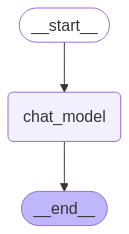

In [11]:
# Node
def chat_model_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"][-1:])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
# Добавляем последнее сообщение из вывода графа
messages.append(output['messages'][-1])

# Добавляем новое сообщение от пользователя
messages.append(HumanMessage(f"Расскажи подробнее о нарвалах!", name="Лэнс"))

In [13]:
# Invoke, using message filtering
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Бот

Привет.
================================ Human Message =================================
Name: Лэнс

Привет.
================================== Ai Message ==================================
Name: Бот

Итак, вы сказали, что изучаете морских млекопитающих?
================================ Human Message =================================
Name: Лэнс

Да, я знаю о китах. Но о каких еще животных мне стоит узнать?
================================== Ai Message ==================================

Отличный выбор! Морские млекопитающие действительно удивительны и разнообразны. Помимо китов, есть множество других интересных видов, которые могут вас заинтересовать. Вот несколько примеров:

1. **Дельфины** – это одни из самых умных морских млекопитающих. Они обладают развитой социальной структурой и сложным языком общения. Дельфины живут как в океанах, так и в реках (например, амазонский дельфин).

2. **Моржи*

==================================================================================

## Обрезка сообщений

Другой подход — [обрезка сообщений](https://python.langchain.com/v0.2/docs/how_to/trim_messages/#getting-the-last-max_tokens-tokens) на основе заданного количества токенов.

Это ограничивает историю сообщений указанным количеством токенов.

В то время как фильтрация возвращает только постфактум подмножество сообщений между агентами, обрезка ограничивает количество токенов, которые чат-модель может использовать для ответа.

Смотрите пример `trim_messages` ниже.

In [14]:
from langchain_core.messages import trim_messages

In [15]:
llm = llm_01 = GigaChat(
    credentials = api_key,
    verify_ssl_certs=False,
    scope = 'GIGACHAT_API_CORP',
    temperature=0.1,
    profanity_check = False,
    model="GigaChat-Max",
)

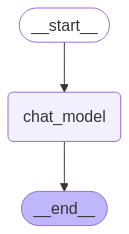

In [16]:
# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens=100,
            strategy="last",
            token_counter=llm,
            allow_partial=False,
        )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Расскажи подробнее о нарвалах!", name="Лэнс"))

In [ ]:
#ytне работает на гигачат

In [18]:
trim_messages(
            messages,
            max_tokens=100,
            strategy="last",
            token_counter=llm,
            allow_partial=False,
        )

[HumanMessage(content='Расскажи подробнее о нарвалах!', additional_kwargs={}, response_metadata={}, name='Лэнс')]

In [19]:
# Invoke, using message trimming in the chat_model_node 
messages_out_trim = graph.invoke({'messages': messages})

In [20]:
messages_out_trim

{'messages': [AIMessage(content='Привет.', additional_kwargs={}, response_metadata={}, name='Бот', id='1'),
  HumanMessage(content='Привет.', additional_kwargs={}, response_metadata={}, name='Лэнс', id='2'),
  AIMessage(content='Итак, вы сказали, что изучаете морских млекопитающих?', additional_kwargs={}, response_metadata={}, name='Бот', id='3'),
  HumanMessage(content='Да, я знаю о китах. Но о каких еще животных мне стоит узнать?', additional_kwargs={}, response_metadata={}, name='Лэнс', id='4'),
  AIMessage(content='Отличный выбор! Морские млекопитающие действительно удивительны и разнообразны. Помимо китов, есть множество других интересных видов, которые могут вас заинтересовать. Вот несколько примеров:\n\n1. **Дельфины** – это одни из самых умных морских млекопитающих. Они обладают развитой социальной структурой и сложным языком общения. Дельфины живут как в океанах, так и в реках (например, амазонский дельфин).\n\n2. **Моржи** – крупные морские млекопитающие с массивными клыками.